# MeatLens MobileNetV3Small Cross-Rotation 6-Fold CNN-Only Notebook

This notebook replicates the `new5` CNN-only setup, but uses the split CSVs from `generated_splits/cross_rotation_6fold/`.

- MobileNetV3Small only
- 6-fold cross-rotation only
- split source: `generated_splits/cross_rotation_6fold/`
- current `file_destination` values point into the `interval sampled` image tree
- no handcrafted RGB/HSV/LAB/GLCM feature branch
- new output root only: `training_outputs/mobilenetv3small_cross_rotation6_cnn_only/`


Transition-aware evaluation note:

Strict accuracy and macro F1 remain the primary evaluation metrics. Transition-aware metrics are added only as secondary analysis because pork freshness changes gradually and borderline images may visually fall between adjacent classes.


In [1]:
import importlib
import inspect

import pandas as pd
from IPython.display import Image as DisplayImage, display

import mobilenetv3small_cross_rotation6_cnn_only_lib as segmented6_lib

segmented6_lib = importlib.reload(segmented6_lib)

print("Library source:", segmented6_lib.__file__)
print(
    "Function first lines:",
    {
        "train_segmented6_cnn_only_model": segmented6_lib.train_segmented6_cnn_only_model.__code__.co_firstlineno,
        "run_single_segmented6_cnn_only_experiment": segmented6_lib.run_single_segmented6_cnn_only_experiment.__code__.co_firstlineno,
    },
)
print(
    "Function source files:",
    {
        "train_segmented6_cnn_only_model": inspect.getsourcefile(segmented6_lib.train_segmented6_cnn_only_model),
        "run_single_segmented6_cnn_only_experiment": inspect.getsourcefile(segmented6_lib.run_single_segmented6_cnn_only_experiment),
    },
)

sanity_optimizer = segmented6_lib.make_optimizer(1e-3)
print("Sanity optimizer type:", type(sanity_optimizer))
print("Sanity optimizer module:", type(sanity_optimizer).__module__)

if inspect.getsourcefile(segmented6_lib.run_single_segmented6_cnn_only_experiment) != segmented6_lib.__file__:
    raise RuntimeError("Notebook is not using the module-backed experiment function.")

if "legacy" not in type(sanity_optimizer).__module__:
    raise RuntimeError("Notebook did not load the DirectML-safe legacy Adam optimizer.")

print("Notebook sanity check passed.")

segmented6_lib.ensure_output_dirs()
segmented6_lib.print_library_status()


[INFO] TensorFlow XLA/JIT disabled.
Library source: e:\Thesis Code\mobilenetv3small_cross_rotation6_cnn_only_lib.py
Function first lines: {'train_segmented6_cnn_only_model': 528, 'run_single_segmented6_cnn_only_experiment': 615}
Function source files: {'train_segmented6_cnn_only_model': 'e:\\Thesis Code\\mobilenetv3small_cross_rotation6_cnn_only_lib.py', 'run_single_segmented6_cnn_only_experiment': 'e:\\Thesis Code\\mobilenetv3small_cross_rotation6_cnn_only_lib.py'}
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Sanity optimizer type: <class 'keras.optimizers.legacy.adam.Adam'>
Sanity optimizer module: keras.optimizers.legacy.adam
Notebook sanity check passed.
TF_AVAILABLE = True
SKLEARN_AVAILABLE = True
SKIMAGE_AVAILABLE = True
CV2_AVAILABLE = True
JOBLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
PROJECT_ROOT = e:\Thesis Code
SEGMENTED_SPLITS_ROOT = e:\Thesis Code\generated_splits\cross_rotation_6fold
EXTENSION_OUTPUT_ROOT = e:\Thesis Code\training_outputs\mo

In [2]:
split_dfs = segmented6_lib.load_all_cross_rotation_splits()
print("Loaded split keys:", sorted(split_dfs.keys()))
resolved_counts = {
    split_key: int(df["image_path_resolved"].notna().sum())
    for split_key, df in split_dfs.items()
}
resolved_counts


Loaded split keys: ['fold1_test', 'fold1_train', 'fold1_val', 'fold2_test', 'fold2_train', 'fold2_val', 'fold3_test', 'fold3_train', 'fold3_val', 'fold4_test', 'fold4_train', 'fold4_val', 'fold5_test', 'fold5_train', 'fold5_val', 'fold6_test', 'fold6_train', 'fold6_val']


{'fold1_train': 2438,
 'fold1_val': 430,
 'fold1_test': 600,
 'fold2_train': 2438,
 'fold2_val': 430,
 'fold2_test': 600,
 'fold3_train': 2508,
 'fold3_val': 442,
 'fold3_test': 518,
 'fold4_train': 2480,
 'fold4_val': 438,
 'fold4_test': 550,
 'fold5_train': 2438,
 'fold5_val': 430,
 'fold5_test': 600,
 'fold6_train': 2438,
 'fold6_val': 430,
 'fold6_test': 600}

In [3]:
metadata_validation_df = segmented6_lib.validate_metadata_mapping(split_dfs)
metadata_validation_df


,sample_id,expected_sample_number,observed_rows,observed_sample_numbers,pork_cut,capture_source,phone_group,missing_image_path_rows
0,pork_shoulder_sample_1,1,3600,1,shoulder,researcher_home,old_phone,0
1,pork_shoulder_sample_2,2,3600,2,shoulder,partner_home,old_phone,0
2,pork_belly_sample_3,3,3108,3,belly,researcher_home,old_phone,0
3,pork_belly_sample_4,4,3300,4,belly,partner_home,old_phone,0
4,pork_ham_sample_5,5,3600,5,ham,researcher_home,new_phone,0
5,pork_ham_sample_6,6,3600,6,ham,partner_home,new_phone,0


In [4]:
quality_bundle = segmented6_lib.build_dataset_quality_summary(split_dfs)
segmented6_lib.print_quality_tables(quality_bundle)
quality_bundle["summary_df"].head(20)


[WARN] Resized non-224 image: E:\Thesis Code\interval sampled\Pork Shoulder - sample 2\Fresh 0-6 hours\IMG20260423061521.jpg | original shape=(1844, 4096, 3)
[WARN] Resized non-224 image: E:\Thesis Code\interval sampled\Pork Belly - Sample 3\Fresh - 0 to 8 hours\20260429_042402.jpg | original shape=(3456, 4608, 3)
[WARN] Resized non-224 image: E:\Thesis Code\interval sampled\Pork Belly - Sample 4\Fresh - 0 to 6 hours\20260429_065044.jpg | original shape=(2304, 4096, 3)
[WARN] Resized non-224 image: E:\Thesis Code\interval sampled\Pork Ham - Sample 5\Fresh - 0 to 8 hours\IMG_20260508_041534.jpg | original shape=(1872, 4160, 3)
[WARN] Resized non-224 image: E:\Thesis Code\interval sampled\Pork Shoulder - sample 2\Fresh 0-6 hours\IMG20260423061821.jpg | original shape=(1844, 4096, 3)
[WARN] Resized non-224 image: E:\Thesis Code\interval sampled\Pork Ham - Sample 6\Fresh - 0 to 7 hours\IMG20260508062519.jpg | original shape=(1844, 4096, 3)
[WARN] Resized non-224 image: E:\Thesis Code\inter

,section,sample_id,count,label,split_name,dataset_partition,fold,held_out_sample,test_contains_held_out_sample,held_out_absent_in_train,held_out_absent_in_val,train_val_overlap,train_test_overlap,val_test_overlap,metric_name,metric_value
0,count_per_sample_id,pork_belly_sample_3,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,count_per_sample_id,pork_belly_sample_4,550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,count_per_sample_id,pork_ham_sample_5,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,count_per_sample_id,pork_ham_sample_6,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,count_per_sample_id,pork_shoulder_sample_1,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,count_per_sample_id,pork_shoulder_sample_2,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,count_per_label,NaN,1068,fresh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,count_per_label,NaN,1200,not fresh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,count_per_label,NaN,1200,spoiled,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,count_per_sample_id_label,pork_belly_sample_3,118,fresh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved sample image figure: e:\Thesis Code\training_outputs\mobilenetv3small_cross_rotation6_cnn_only_centercrop\figures\segmented_roi_sample_images.png


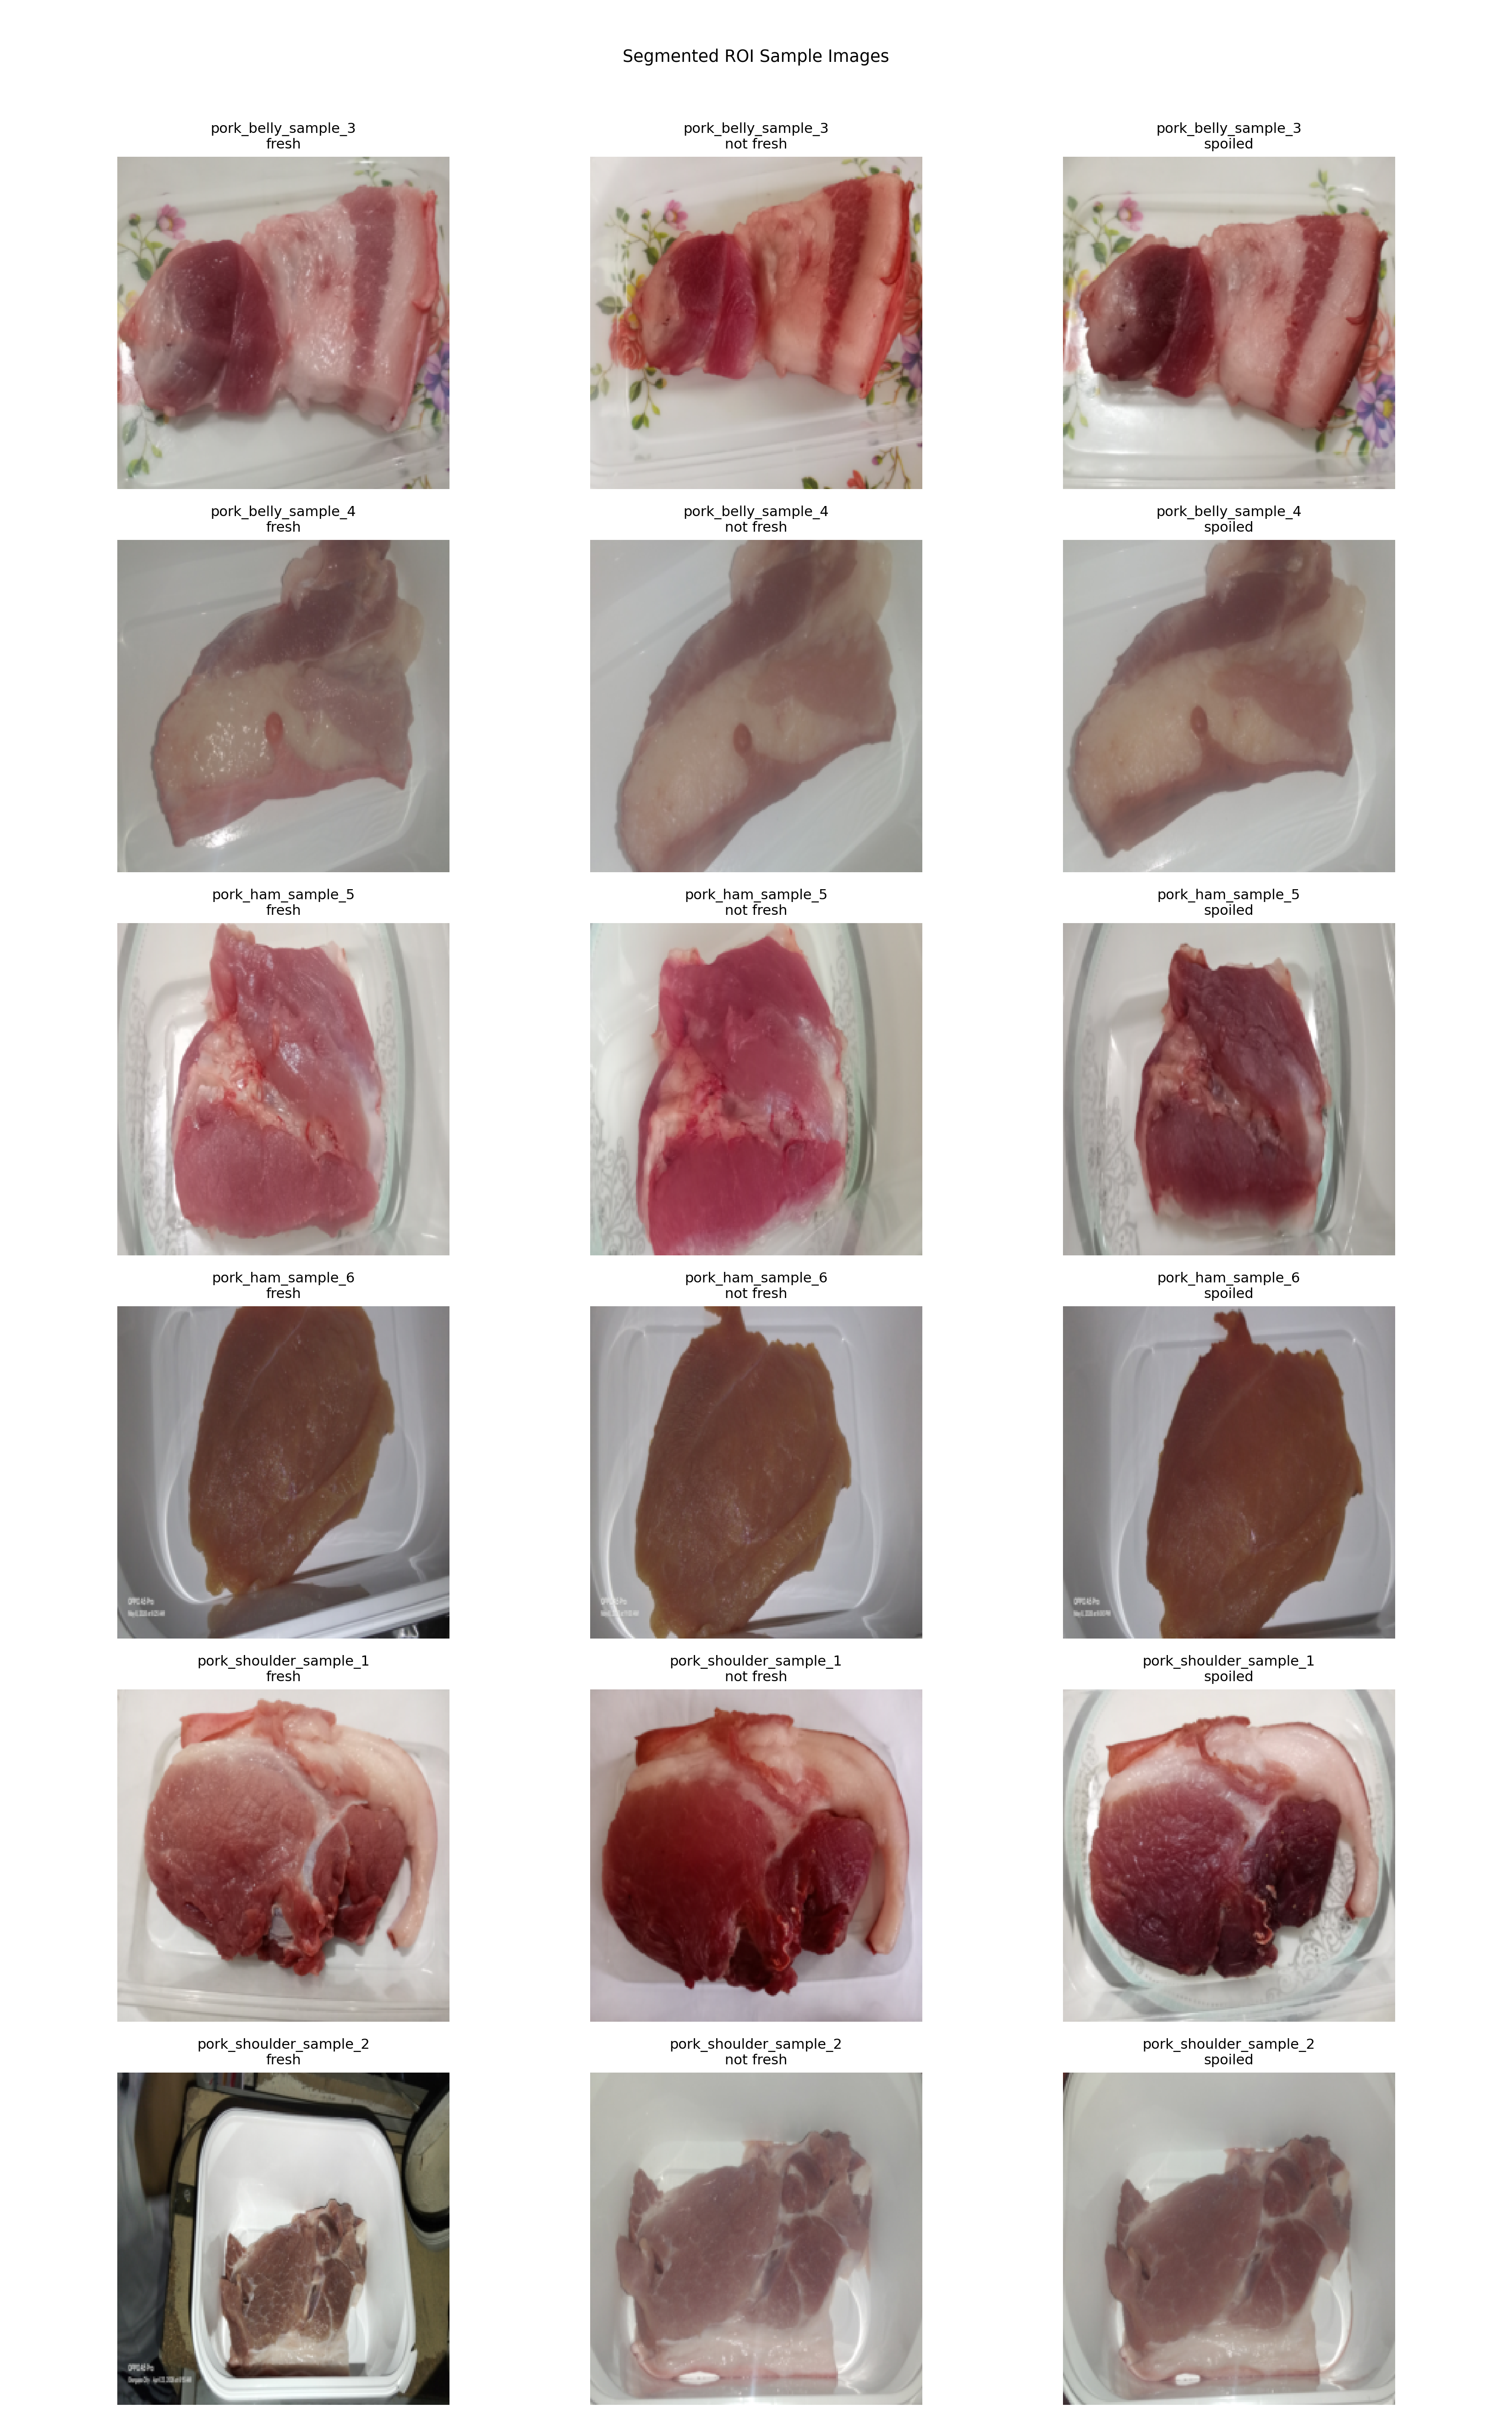

In [5]:
sample_image_figure_path = segmented6_lib.save_sample_visualization(split_dfs)
print("Saved sample image figure:", sample_image_figure_path)
display(DisplayImage(filename=str(sample_image_figure_path)))


In [6]:
print("Dataset quality summary CSV:", segmented6_lib.SEGMENTED6_QUALITY_SUMMARY_PATH)
print("Cross-rotation 6-fold split root:", segmented6_lib.SEGMENTED_SPLITS_ROOT)
print("Output root:", segmented6_lib.EXTENSION_OUTPUT_ROOT)
print("Comparison CSV path:", segmented6_lib.SEGMENTED6_COMPARISON_PATH)


Dataset quality summary CSV: e:\Thesis Code\training_outputs\mobilenetv3small_cross_rotation6_cnn_only_centercrop\cross_rotation6_dataset_quality_summary.csv
Cross-rotation 6-fold split root: e:\Thesis Code\generated_splits\cross_rotation_6fold
Output root: e:\Thesis Code\training_outputs\mobilenetv3small_cross_rotation6_cnn_only_centercrop
Comparison CSV path: e:\Thesis Code\training_outputs\mobilenetv3small_cross_rotation6_cnn_only_centercrop\cross_rotation6_hybrid_vs_cnn_only_centercrop_comparison.csv


In [7]:
import inspect

source = inspect.getsource(segmented6_lib.train_segmented6_cnn_only_model)
print("Contains ModelCheckpoint?", "ModelCheckpoint" in source)
print("Contains load_weights?", "load_weights" in source)
print("Contains .weights.h5?", ".weights.h5" in source)
print("Contains feature_input?", "feature_input" in source)
print("Contains Concatenate?", "Concatenate" in source)


Contains ModelCheckpoint? False
Contains load_weights? False
Contains .weights.h5? False
Contains feature_input? False
Contains Concatenate? False


## Comparison Section

This section compares the completed hybrid metrics CSV against the CNN-only metrics CSV after CNN-only training has finished.


In [8]:
comparison_bundle = segmented6_lib.create_hybrid_vs_cnn_only_comparison()
if comparison_bundle is not None:
    comparison_bundle["comparison_df"]


CNN-only metrics not found: e:\Thesis Code\training_outputs\mobilenetv3small_cross_rotation6_cnn_only_centercrop\cross_rotation6_cnn_only_centercrop_seed_metrics.csv


## Manual Full Training Cell


In [9]:
MANUAL_CONFIRM_RUN_CNN_ONLY_TRAINING = True

if MANUAL_CONFIRM_RUN_CNN_ONLY_TRAINING:
    RUN_EXTENSION_TRAINING = True
    segmented6_lib.RUN_EXTENSION_TRAINING = RUN_EXTENSION_TRAINING
    all_results = segmented6_lib.run_segmented6_cnn_only_training()
else:
    print("CNN-only cross_rotation_6fold training is ready but not started.")
    print("Set MANUAL_CONFIRM_RUN_CNN_ONLY_TRAINING = True to train.")


Running segmented CNN-only experiment: fold1 seed=42
[DATA] fold1 seed=42
  train_images count=2438 loaded_per_batch=32
  val_images count=430 loaded_per_batch=32
  test_images count=600 loaded_per_batch=32
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
[INFO] Compiled optimizer: keras.optimizers.legacy.adam.Adam
Epoch 1/8
 - val_f1_macro: 0.9072
77/77 - 365s - loss: 0.8233 - accuracy: 0.6399 - val_loss: 0.3361 - val_accuracy: 0.9047 - val_f1_macro: 0.9072 - lr: 5.0000e-04 - 365s/epoch - 5s/step
Epoch 2/8
 - val_f1_macro: 0.9144
77/77 - 362s - loss: 0.3902 - accuracy: 0.8568 - val_loss: 0.2309 - val_accuracy: 0.9116 - val_f1_macro: 0.9144 - lr: 5.0000e-04 - 362s/epoch - 5s/step
Epoch 3/8
 - val_f1_macro: 0.9549
77/77 - 361s - loss: 0.2808 - accuracy: 0.8864 - val_loss: 0.1769 - val_accuracy: 0.9535 - val_f1_macro: 0.9549 - lr: 5.0000e-04 - 361s/epoch - 5s/step
Epoch 4/8
 - val_f1_macro: 0.9458
77/77 - 357s - loss: 0.2257 - accuracy: 0.9184 - val_loss: 0.1533 -

KeyboardInterrupt: 

In [ ]:
# debug_result = segmented6_lib.run_single_segmented6_cnn_only_experiment(
#     fold_name="fold1",
#     seed=42,
# )
